# Seoul Bike Sharing Demand Prediction

## Regression Track

### Problem Statement

The objective of this project is to predict the number of bikes rented
using information such as time, weather conditions, season, holiday status,
and whether the day is functioning.

The target variable for the regression task is:

**Rented Bike Count**

The regression pipeline includes:

1. Dataset loading and auditing
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature engineering
5. Data preprocessing
6. Train-test splitting
7. Training multiple regression algorithms
8. Model comparison
9. Hyperparameter tuning
10. Cross-validation
11. Final model evaluation
12. Result visualization

## 1. Import Required Libraries

The following Python libraries are used for:

- Data manipulation: Pandas, NumPy
- Data visualization: Matplotlib, Seaborn
- Data preprocessing: Scikit-learn
- Regression algorithms: Scikit-learn
- Model evaluation: Scikit-learn

In [7]:
# ==============================
# Import Required Libraries
# ==============================

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test splitting and cross-validation
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression algorithms
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set random state for reproducibility
RANDOM_STATE = 42

## 2. Load the Dataset

The Seoul Bike Sharing dataset is loaded from the `data` directory.

The dataset contains information about bike rentals along with
weather, time, seasonal, holiday, and functioning-day information.

In [8]:
# Load the Seoul Bike dataset
# The dataset contains special characters in some column names,
# therefore latin1 encoding is used.

df = pd.read_csv(
    "../data/SeoulBikeData.csv",
    encoding="latin1"
)

# Display the first five rows
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 3. Dataset Audit

Before performing analysis or building models, the dataset must be audited.

The following checks will be performed:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Statistical summary
- Target variable distribution

This helps identify potential data-quality problems before preprocessing.

In [9]:
# Display the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8760
Number of columns: 14


In [10]:
# Display all column names
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Date
2. Rented Bike Count
3. Hour
4. Temperature(°C)
5. Humidity(%)
6. Wind speed (m/s)
7. Visibility (10m)
8. Dew point temperature(°C)
9. Solar Radiation (MJ/m2)
10. Rainfall(mm)
11. Snowfall (cm)
12. Seasons
13. Holiday
14. Functioning Day


In [11]:
# Display dataset information including:
# - column names
# - non-null counts
# - data types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [12]:
# Generate descriptive statistics for numerical columns

df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [13]:
# Check for missing values in every column

missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

Missing values in each column:

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


In [14]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
# Display the unique values of categorical columns

categorical_columns = df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Date
<StringArray>
['01/12/2017', '02/12/2017', '03/12/2017', '04/12/2017', '05/12/2017',
 '06/12/2017', '07/12/2017', '08/12/2017', '09/12/2017', '10/12/2017',
 ...
 '21/11/2018', '22/11/2018', '23/11/2018', '24/11/2018', '25/11/2018',
 '26/11/2018', '27/11/2018', '28/11/2018', '29/11/2018', '30/11/2018']
Length: 365, dtype: str

Seasons
<StringArray>
['Winter', 'Spring', 'Summer', 'Autumn']
Length: 4, dtype: str

Holiday
<StringArray>
['No Holiday', 'Holiday']
Length: 2, dtype: str

Functioning Day
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


### Dataset Audit Observations

Based on the dataset audit:

- The dataset contains 8,760 observations and 14 columns.
- The target variable is `Rented Bike Count`.
- Numerical and categorical variables are present.
- Missing-value counts are checked before preprocessing.
- Duplicate records are also checked.

[WRITE YOUR OWN OBSERVATION BASED ON THE OUTPUT ABOVE.]

# 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand:

- The distribution of numerical variables
- The distribution of the target variable
- Relationships between features and bike rentals
- Correlations between numerical variables
- Differences in bike rentals across categorical variables

The observations from EDA will help us understand the dataset
before building regression models.

In [16]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']


## 4.1 Distribution of Numerical Features

Histograms are used to understand the distribution and spread
of each numerical variable.

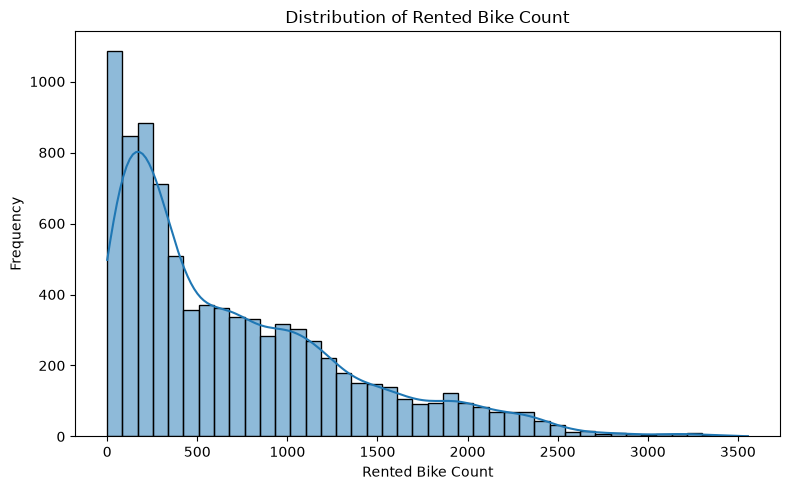

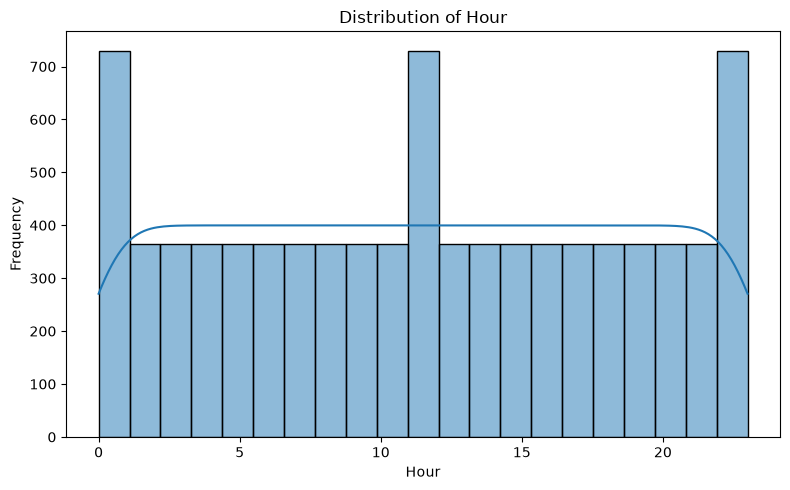

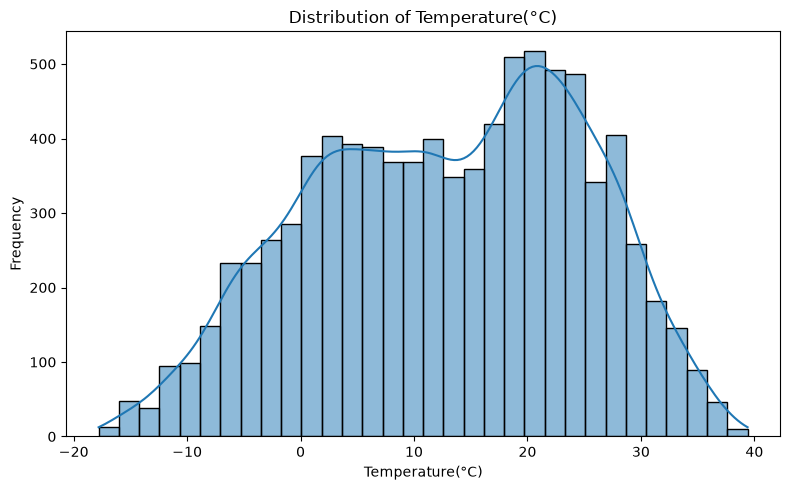

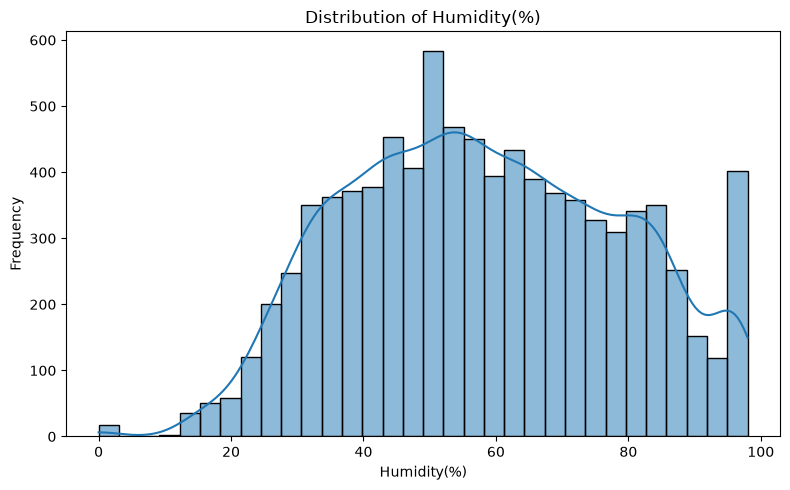

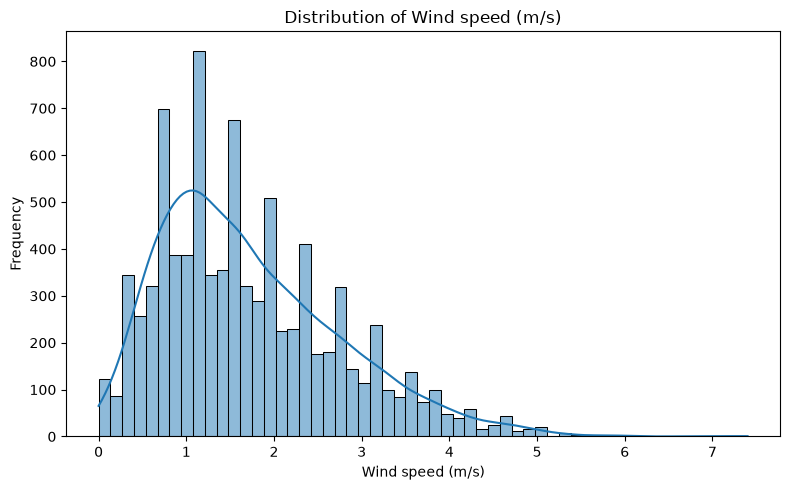

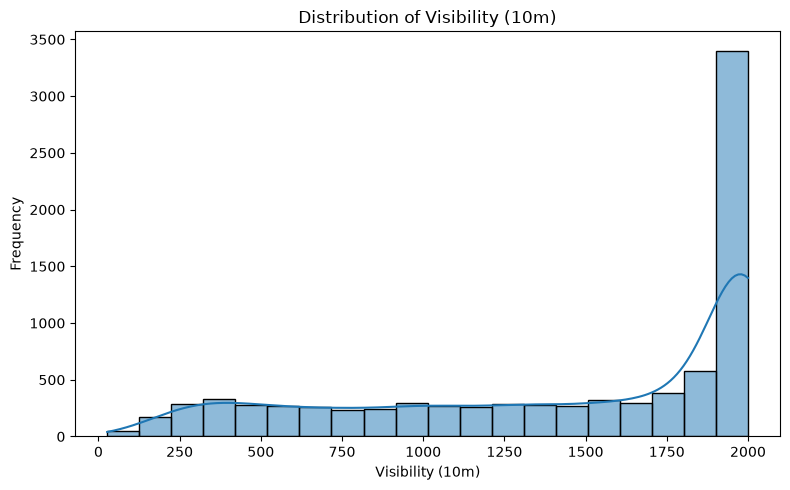

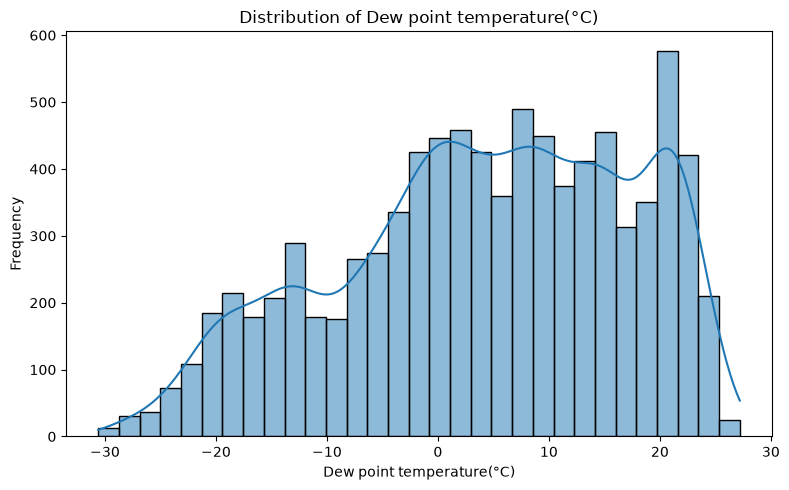

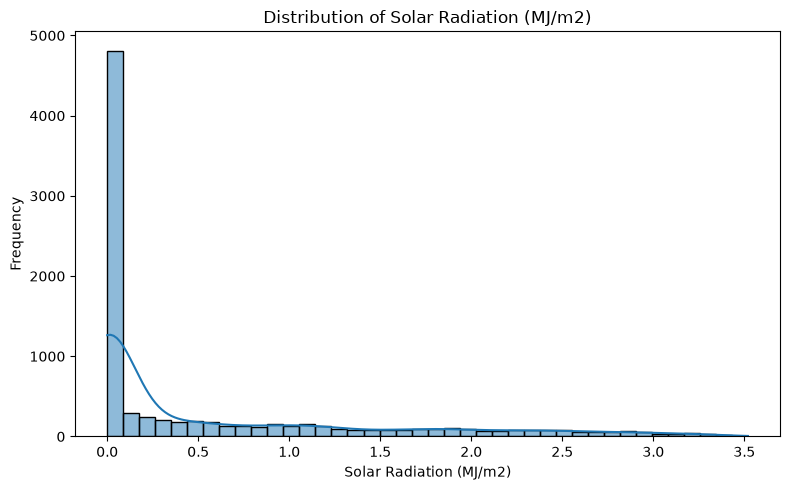

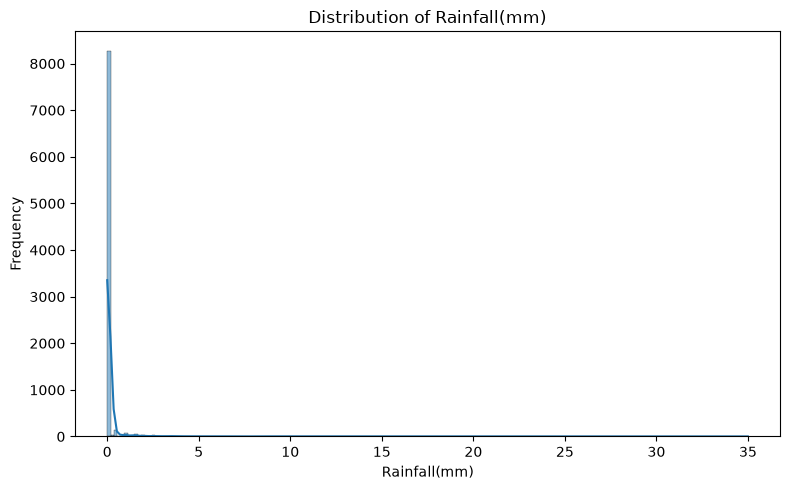

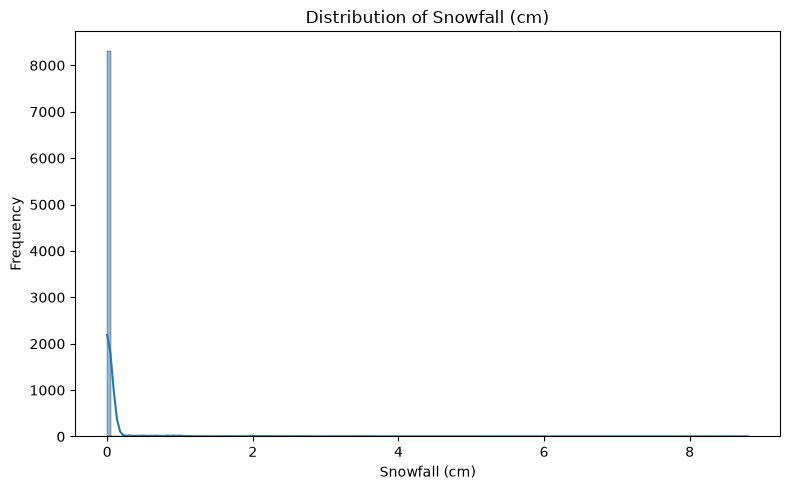

In [17]:
# Plot distributions for all numerical variables

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### EDA Observation

The distribution plots show the spread and shape of the numerical
variables in the dataset.

[WRITE YOUR OWN OBSERVATIONS AFTER LOOKING AT THE PLOTS.]

For example, mention if a variable appears:
- approximately symmetric
- right/left skewed
- concentrated within a particular range
- affected by extreme values

## 4.2 Target Variable Distribution

The target variable `Rented Bike Count` is visualized separately
because it is the variable that the regression models will predict.

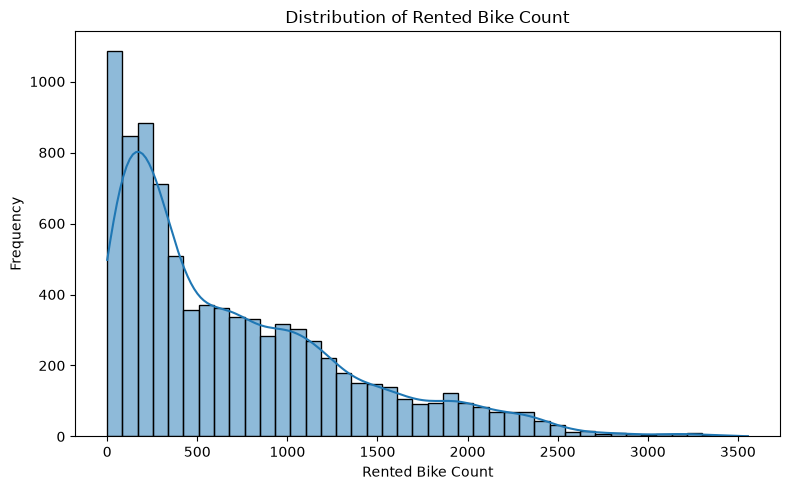

In [18]:
# Plot the distribution of the target variable

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rented Bike Count",
    kde=True
)

plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

[WRITE YOUR OWN OBSERVATION ABOUT THE TARGET DISTRIBUTION.]

Consider:
- Is the target approximately symmetric?
- Is it skewed?
- Are there very high or low rental counts?

## 4.3 Correlation Analysis

A correlation heatmap is used to examine the linear relationships
between numerical variables.

Correlation values range from -1 to +1:

- +1 indicates a strong positive linear relationship.
- -1 indicates a strong negative linear relationship.
- 0 indicates little or no linear relationship.

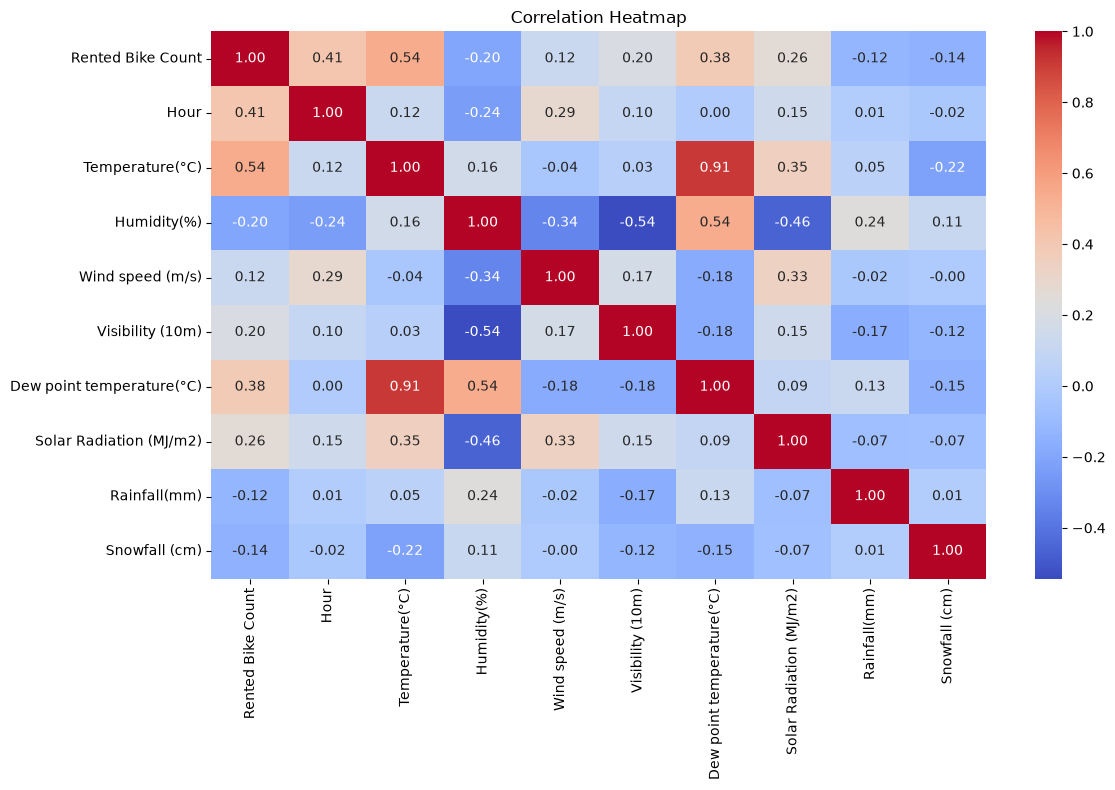

In [19]:
# Calculate correlation matrix for numerical variables

correlation_matrix = df[numerical_columns].corr()

# Plot the correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Observation

[WRITE YOUR OWN OBSERVATION FROM THE HEATMAP.]

Identify:
- variables that appear positively correlated with bike rentals
- variables that appear negatively correlated with bike rentals
- highly correlated predictor variables, if present

## 4.4 Feature-Target Relationship: Hour

The relationship between `Hour` and `Rented Bike Count` is
visualized to investigate whether rental demand changes
throughout the day.

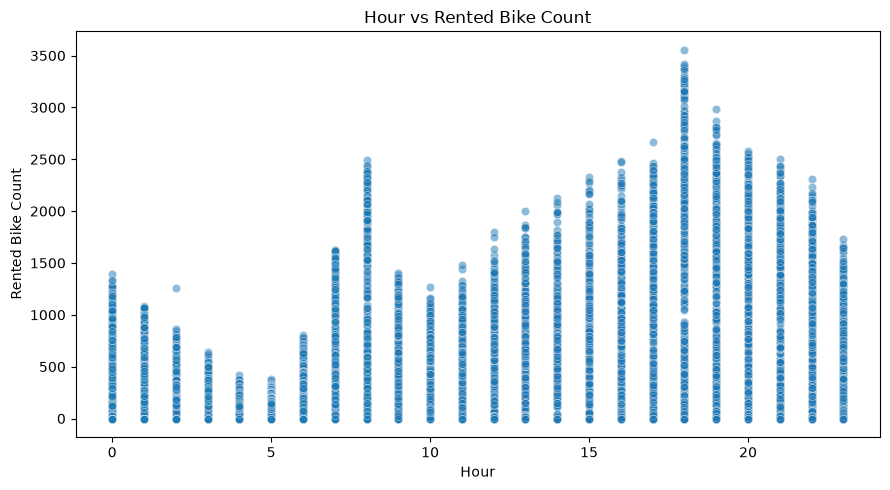

In [20]:
# Plot Hour against Rented Bike Count

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Hour",
    y="Rented Bike Count",
    alpha=0.5
)

plt.title("Hour vs Rented Bike Count")
plt.xlabel("Hour")
plt.ylabel("Rented Bike Count")

plt.tight_layout()
plt.show()

### Observation

[WRITE YOUR OWN OBSERVATION FROM THE PLOT.]

Look for patterns in bike demand at different hours of the day.

## 4.5 Feature-Target Relationship: Temperature

The relationship between temperature and bike rental demand
is examined using a scatter plot.

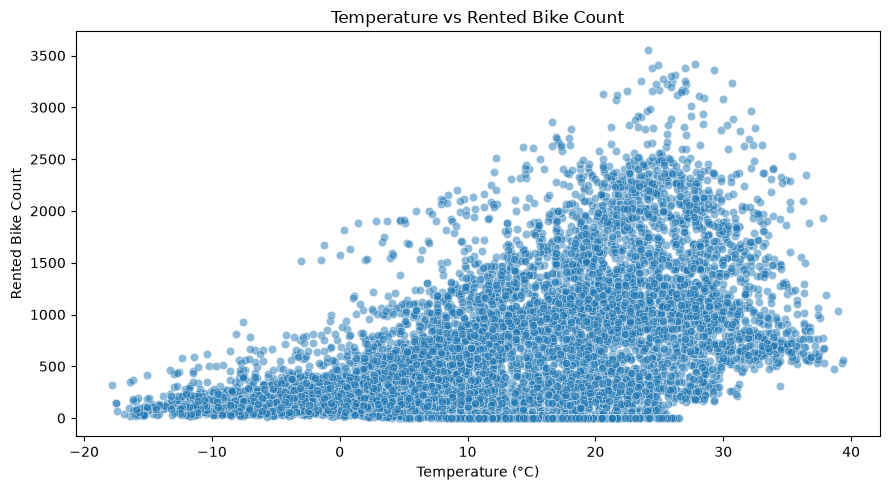

In [21]:
# Plot Temperature against Rented Bike Count

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Temperature(°C)",
    y="Rented Bike Count",
    alpha=0.5
)

plt.title("Temperature vs Rented Bike Count")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rented Bike Count")

plt.tight_layout()
plt.show()

### Observation

[WRITE YOUR OWN OBSERVATION FROM THE PLOT.]

## 4.6 Categorical Feature Analysis

Categorical variables such as season, holiday status, and
functioning-day status are compared against bike rental demand.

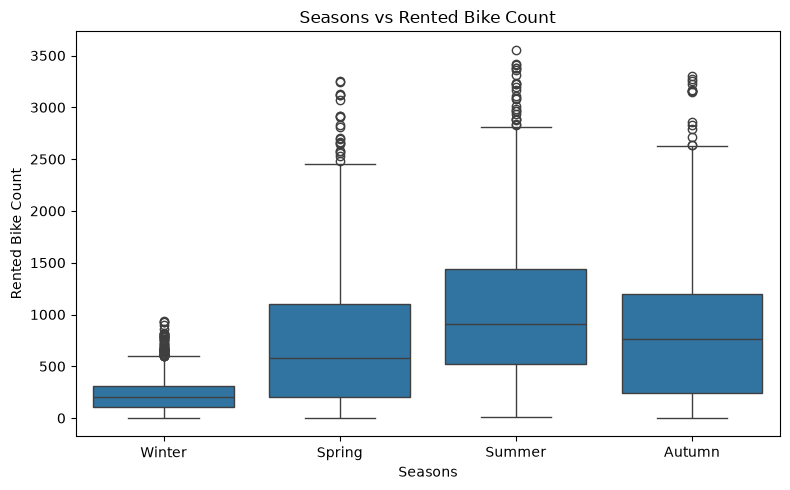

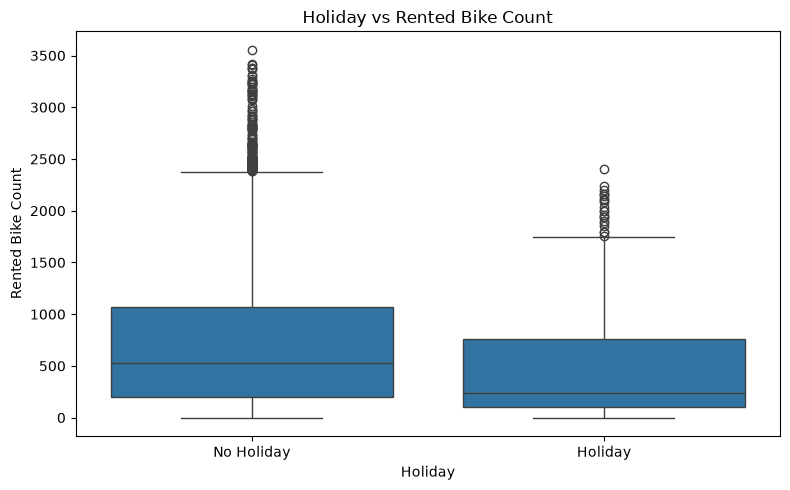

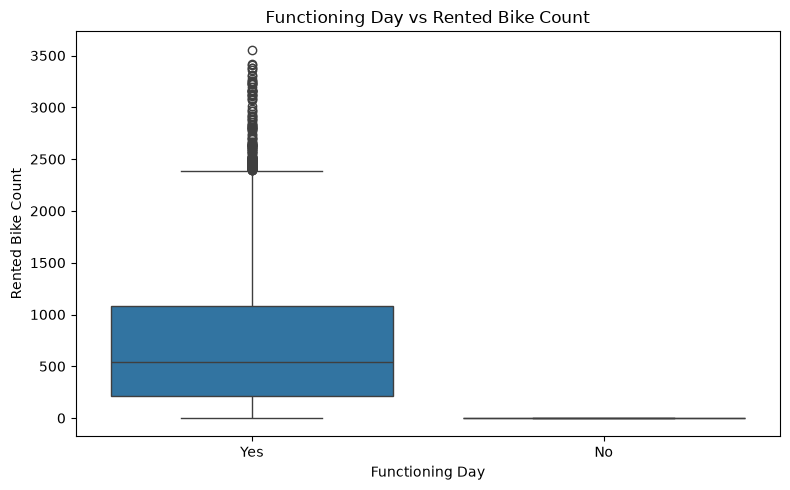

In [22]:
# Box plots for important categorical variables

categorical_features_for_eda = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

for column in categorical_features_for_eda:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=column,
        y="Rented Bike Count"
    )

    plt.title(f"{column} vs Rented Bike Count")
    plt.xlabel(column)
    plt.ylabel("Rented Bike Count")

    plt.tight_layout()
    plt.show()

### Observation

[WRITE YOUR OWN OBSERVATION FOR EACH CATEGORICAL FEATURE.]

Discuss visible differences in bike rental distributions between
the categories.

# 5. Data Cleaning

Before training machine learning models, the dataset is checked for:

1. Missing values
2. Duplicate records
3. Invalid data types
4. Potential outliers

The cleaning decisions are based on the characteristics of the dataset.

In [23]:
# Check missing values again before cleaning

print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

Missing values:
Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

Total missing values: 0


In [24]:
# Check duplicate records

print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


## 5.1 Convert Date Column

The `Date` column is currently stored as text.

Instead of using the raw date string directly, it will be converted
into a datetime object so that useful time-related features such as
year, month, day, and day of week can be extracted.

In [25]:
# Convert Date from string to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d/%m/%Y"
)

# Verify the conversion

print(df["Date"].dtype)

datetime64[us]


In [26]:
# Display the earliest and latest dates

print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

Minimum date: 2017-12-01 00:00:00
Maximum date: 2018-11-30 00:00:00


## 5.2 Outlier Inspection

Box plots are used to identify potential extreme observations.

An extreme value is not automatically removed because it may represent
a genuine observation, such as unusually high demand or unusual
weather conditions.

Therefore, the plots are used for inspection before deciding whether
any treatment is necessary.

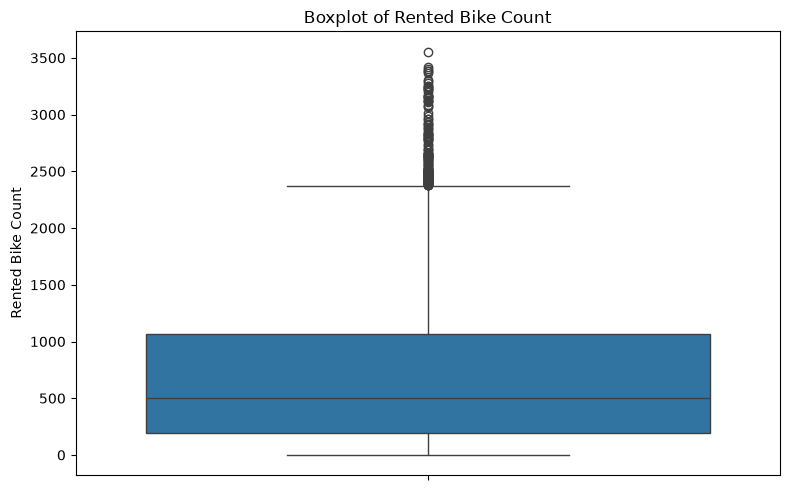

In [27]:
# Boxplot for the target variable

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df["Rented Bike Count"]
)

plt.title("Boxplot of Rented Bike Count")
plt.ylabel("Rented Bike Count")

plt.tight_layout()
plt.show()

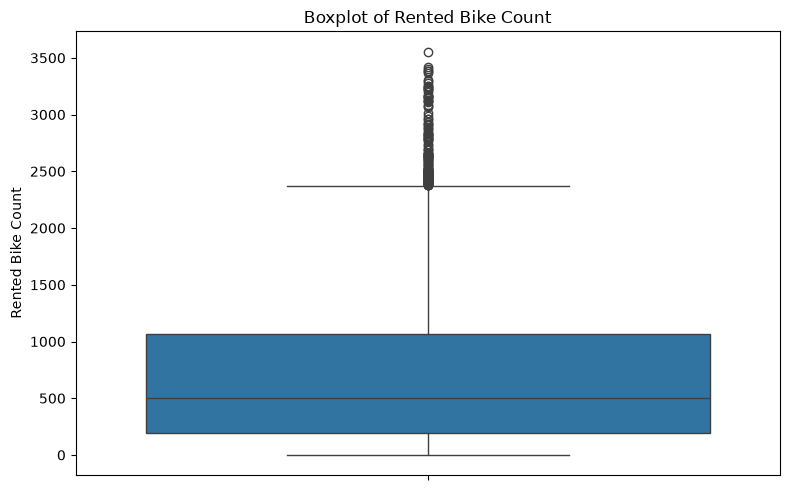

In [28]:
# Boxplot for the target variable

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df["Rented Bike Count"]
)

plt.title("Boxplot of Rented Bike Count")
plt.ylabel("Rented Bike Count")

plt.tight_layout()
plt.show()

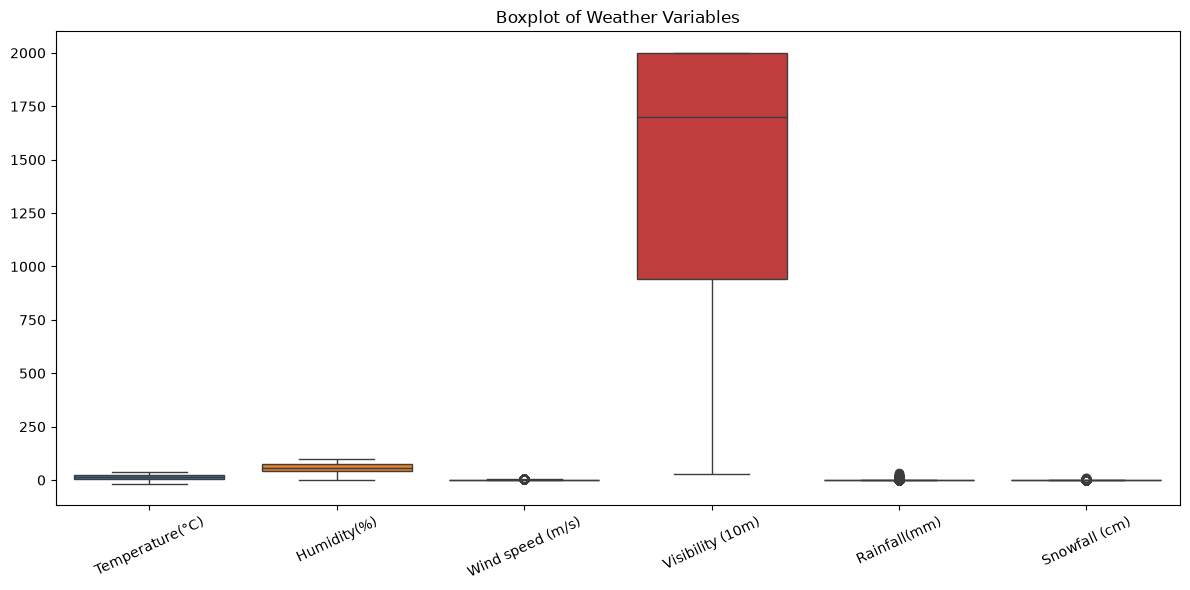

In [29]:
# Boxplots for selected weather variables

weather_columns = [
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Rainfall(mm)",
    "Snowfall (cm)"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[weather_columns]
)

plt.title("Boxplot of Weather Variables")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

### Outlier Observation

[WRITE YOUR OWN OBSERVATION.]

Identify whether extreme observations are visible.

Explain whether they appear to be genuine observations or whether
there is evidence that they are invalid values.

No observations should be removed without justification.

# 6. Feature Engineering

Feature engineering creates additional variables from existing
information that may help the regression models learn useful patterns.

The `Date` column can be used to derive:

- Year
- Month
- Day
- Day of week
- Weekend indicator

These features allow the models to use temporal information
contained in the original date.

In [30]:
# Extract useful temporal features from Date

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [31]:
# Create a weekend indicator
# Saturday = 5 and Sunday = 6

df["Is_Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

# Display the newly created features

df[
    [
        "Date",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "Is_Weekend"
    ]
].head()

,Date,Year,Month,Day,DayOfWeek,Is_Weekend
0,2017-12-01,2017,12,1,4,0
1,2017-12-01,2017,12,1,4,0
2,2017-12-01,2017,12,1,4,0
3,2017-12-01,2017,12,1,4,0
4,2017-12-01,2017,12,1,4,0


## Feature Engineering Justification

The `Is_Weekend` feature was created from `DayOfWeek`.

This feature separates weekdays from weekends and may capture
differences in bike rental behavior caused by different daily
activity patterns.

[REWRITE THIS IN YOUR OWN WORDS AND ADD YOUR OWN REASONING.]

In [32]:
# The useful information from Date has already been extracted.
# Therefore, the original datetime column is removed.

df.drop(
    columns=["Date"],
    inplace=True
)

# Verify the remaining columns

df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Year', 'Month', 'Day', 'DayOfWeek',
       'Is_Weekend'],
      dtype='str')

# 7. Define Features and Target

The regression target is:

`Rented Bike Count`

All remaining variables are used as input features.

Therefore:

- X = predictor variables
- y = target variable

In [33]:
# Separate input features and target

X = df.drop(
    columns=["Rented Bike Count"]
)

y = df["Rented Bike Count"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8760, 17)
Target shape: (8760,)


# 8. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to fit the models, while the test data
is kept separate for final evaluation.

A random state of 42 is used to make the split reproducible.

In [34]:
# Create bins of the target variable for approximately
# maintaining a similar target distribution in train and test sets.

y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 7008
Testing samples: 1752


# 9. Data Preprocessing

The dataset contains both numerical and categorical variables.

### Numerical variables

Numerical features will be standardized using `StandardScaler`.

### Categorical variables

Categorical features will be converted into numerical form using
One-Hot Encoding.

A `ColumnTransformer` is used so that the appropriate transformation
is applied to each type of feature.

The preprocessing will be placed inside a Pipeline to prevent
data leakage. The scaler and encoder will be fitted only using
the training data.

In [35]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Is_Weekend']

Categorical features:
['Seasons', 'Holiday', 'Functioning Day']


In [36]:
# Preprocessing pipeline for numerical features

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Preprocessing pipeline for categorical features

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [37]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# 10. Regression Model Training

The following 10 regression algorithms will be trained using
the same training dataset and evaluated on the same held-out
test dataset.

### Required Algorithms

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor

The same preprocessing strategy and train-test split will be
used to ensure a fair comparison.

In [38]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

## 5.1 Linear Regression

Linear Regression is used as the baseline regression model.

It models the relationship between the input features and the target variable by fitting a linear equation.

The model is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [48]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create Linear Regression pipeline
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_pipeline.predict(X_test)

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

# Store results
linear_result = {
    "Model": "Linear Regression",
    "MAE": linear_mae,
    "MSE": linear_mse,
    "RMSE": linear_rmse,
    "R2": linear_r2
}

# Display results
linear_result_df = pd.DataFrame([linear_result])

print("Linear Regression Results:")
display(linear_result_df)

print("Linear Regression completed successfully.")

Linear Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,326.009637,186274.677449,431.595502,0.551437


Linear Regression completed successfully.


## 5.2 Ridge Regression

Ridge Regression is a regularized version of Linear Regression.

It uses L2 regularization to reduce the effect of large coefficients and help control model complexity.

The initial value of alpha is set to 1.0.

In [49]:
# Import Ridge Regression
from sklearn.linear_model import Ridge

# Create Ridge Regression pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

# Train the model
ridge_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_pipeline.predict(X_test)

# Calculate evaluation metrics
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

# Store results
ridge_result = {
    "Model": "Ridge Regression",
    "MAE": ridge_mae,
    "MSE": ridge_mse,
    "RMSE": ridge_rmse,
    "R2": ridge_r2
}

# Display results
ridge_result_df = pd.DataFrame([ridge_result])

print("Ridge Regression Results:")
display(ridge_result_df)

print("Ridge Regression completed successfully.")

Ridge Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Ridge Regression,326.012885,186293.399705,431.617191,0.551392


Ridge Regression completed successfully.


## 5.3 Lasso Regression

Lasso Regression applies L1 regularization.

L1 regularization can reduce some model coefficients toward zero, which can help with feature selection.

The initial alpha is set to 0.01.

In [50]:
# Import Lasso Regression
from sklearn.linear_model import Lasso

# Create Lasso Regression pipeline
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]
)

# Train the model
lasso_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lasso = lasso_pipeline.predict(X_test)

# Calculate evaluation metrics
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)

# Store results
lasso_result = {
    "Model": "Lasso Regression",
    "MAE": lasso_mae,
    "MSE": lasso_mse,
    "RMSE": lasso_rmse,
    "R2": lasso_r2
}

# Display results
lasso_result_df = pd.DataFrame([lasso_result])

print("Lasso Regression Results:")
display(lasso_result_df)

print("Lasso Regression completed successfully.")

Lasso Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Lasso Regression,326.009797,186278.356417,431.599764,0.551428


Lasso Regression completed successfully.


## 5.4 ElasticNet Regression

ElasticNet Regression combines both L1 and L2 regularization.

It combines the properties of Lasso and Ridge Regression.

The initial parameters are:
- alpha = 0.01
- l1_ratio = 0.5

In [51]:
# Import ElasticNet Regression
from sklearn.linear_model import ElasticNet

# Create ElasticNet Regression pipeline
elasticnet_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000
        ))
    ]
)

# Train the model
elasticnet_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_elasticnet = elasticnet_pipeline.predict(X_test)

# Calculate evaluation metrics
elasticnet_mae = mean_absolute_error(y_test, y_pred_elasticnet)
elasticnet_mse = mean_squared_error(y_test, y_pred_elasticnet)
elasticnet_rmse = np.sqrt(elasticnet_mse)
elasticnet_r2 = r2_score(y_test, y_pred_elasticnet)

# Store results
elasticnet_result = {
    "Model": "ElasticNet Regression",
    "MAE": elasticnet_mae,
    "MSE": elasticnet_mse,
    "RMSE": elasticnet_rmse,
    "R2": elasticnet_r2
}

# Display results
elasticnet_result_df = pd.DataFrame([elasticnet_result])

print("ElasticNet Regression Results:")
display(elasticnet_result_df)

print("ElasticNet Regression completed successfully.")

ElasticNet Regression Results:


,Model,MAE,MSE,RMSE,R2
0,ElasticNet Regression,326.218372,187054.097227,432.497511,0.54956


ElasticNet Regression completed successfully.


## 5.5 Polynomial Regression

Polynomial Regression extends Linear Regression by adding polynomial features.

Here, PolynomialFeatures with degree 2 is used before Linear Regression.

This allows the model to capture nonlinear relationships between the features and target.

In [52]:
# Import Polynomial Regression components
from sklearn.preprocessing import PolynomialFeatures

# Create Polynomial Regression pipeline
polynomial_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("polynomial", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("model", LinearRegression())
    ]
)

# Train the model
polynomial_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_poly = polynomial_pipeline.predict(X_test)

# Calculate evaluation metrics
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, y_pred_poly)

# Create the polynomial result
poly_result = {
    "Model": "Polynomial Regression",
    "MAE": poly_mae,
    "MSE": poly_mse,
    "RMSE": poly_rmse,
    "R2": poly_r2
}

# Display results
poly_result_df = pd.DataFrame([poly_result])

print("Polynomial Regression Results:")
display(poly_result_df)

print("Polynomial Regression completed successfully.")

Polynomial Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression,247.484595,123580.334268,351.539947,0.70241


Polynomial Regression completed successfully.


## 5.6 Decision Tree Regression

Decision Tree Regression predicts the target by recursively splitting the data into smaller groups based on feature values.

The model can capture nonlinear relationships without requiring the data to follow a linear relationship.

In [53]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_pipeline.predict(X_test)

# Calculate evaluation metrics
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

# Store results
decision_tree_result = {
    "Model": "Decision Tree Regression",
    "MAE": dt_mae,
    "MSE": dt_mse,
    "RMSE": dt_rmse,
    "R2": dt_r2
}

# Display results
decision_tree_result_df = pd.DataFrame([decision_tree_result])

print("Decision Tree Regression Results:")
display(decision_tree_result_df)

print("Decision Tree Regression completed successfully.")

Decision Tree Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Decision Tree Regression,141.885845,59174.31621,243.257716,0.857504


Decision Tree Regression completed successfully.


## 5.7 Random Forest Regression

Random Forest Regression is an ensemble learning method that combines multiple decision trees.

Each tree produces a prediction, and the final prediction is obtained by averaging the predictions of the individual trees.

This generally provides a more robust model than using a single decision tree.

In [54]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_pipeline.predict(X_test)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

# Store results
random_forest_result = {
    "Model": "Random Forest Regression",
    "MAE": rf_mae,
    "MSE": rf_mse,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

# Display results
random_forest_result_df = pd.DataFrame([random_forest_result])

print("Random Forest Regression Results:")
display(random_forest_result_df)

print("Random Forest Regression completed successfully.")

Random Forest Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Random Forest Regression,105.051119,28283.811746,168.177917,0.931891


Random Forest Regression completed successfully.


## 5.8 Gradient Boosting Regression

Gradient Boosting Regression is an ensemble learning technique that builds models sequentially.

Each new tree attempts to improve the errors made by the previous trees.

The final model combines the predictions from all the weak learners.

In [55]:
# Import Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting pipeline
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

# Train the model
gradient_boosting_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_gb = gradient_boosting_pipeline.predict(X_test)

# Calculate evaluation metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

# Store results
gradient_boosting_result = {
    "Model": "Gradient Boosting Regression",
    "MAE": gb_mae,
    "MSE": gb_mse,
    "RMSE": gb_rmse,
    "R2": gb_r2
}

# Display results
gradient_boosting_result_df = pd.DataFrame([gradient_boosting_result])

print("Gradient Boosting Regression Results:")
display(gradient_boosting_result_df)

print("Gradient Boosting Regression completed successfully.")

Gradient Boosting Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting Regression,169.186664,61437.68295,247.86626,0.852054


Gradient Boosting Regression completed successfully.


## 5.9 Support Vector Regression (SVR)

Support Vector Regression is the regression version of Support Vector Machines.

SVR attempts to find a function that predicts the target values while allowing a specified margin of error.

The RBF kernel is used to capture nonlinear relationships.

In [56]:
# Import Support Vector Regressor
from sklearn.svm import SVR

# Create SVR pipeline
svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(
            kernel="rbf"
        ))
    ]
)

# Train the model
svr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_svr = svr_pipeline.predict(X_test)

# Calculate evaluation metrics
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, y_pred_svr)

# Store results
svr_result = {
    "Model": "Support Vector Regression",
    "MAE": svr_mae,
    "MSE": svr_mse,
    "RMSE": svr_rmse,
    "R2": svr_r2
}

# Display results
svr_result_df = pd.DataFrame([svr_result])

print("Support Vector Regression Results:")
display(svr_result_df)

print("Support Vector Regression completed successfully.")

Support Vector Regression Results:


,Model,MAE,MSE,RMSE,R2
0,Support Vector Regression,361.57348,277728.542083,526.999566,0.33121


Support Vector Regression completed successfully.
